# 04 — Next steps: filling the gaps

Each section here matches one gap from that document and is meant to be run **after** the three existing notebooks have produced `data/cleaned/dpe_clean_model_ready.parquet`.

Sections:
1. Setup, paths, reusable preprocessor
2. Wider model menu (`make_model_zoo`) 
3. Hyper-parameter tuning with `RandomizedSearchCV` 
4. Richer evaluation (ROC, PR, calibration, residuals)
5. Permutation importance / SHAP 
6. Leakage ablation on boosted models
7. Fair regression-vs-classification comparison
8. Class-imbalance experiments (SMOTE + threshold tuning) 
9. Pick a champion per task, persist it 
10. Presentation-ready figures 
11. Export `requirements.txt` 


## 1. Setup, paths, reusable preprocessor

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder,
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

# ----- FAST_MODE knob (single flag for dev-vs-final runs) ----------------
# True  -> 10k training rows, 12 tuning trials, 3-fold CV. Total wall-clock ~5 min.
# False -> full training set, 60 tuning trials, 5-fold CV. Total wall-clock ~60-90 min.
# The 20% test set is NEVER subsampled — final metrics stay comparable across modes.
FAST_MODE = True

if FAST_MODE:
    SAMPLE_FOR_DEV = 10_000
    N_ITER_TUNING = 12
    CV_FOLDS = 3
else:
    SAMPLE_FOR_DEV = None
    N_ITER_TUNING = 60
    CV_FOLDS = 5

print(f"FAST_MODE={FAST_MODE} | sample={SAMPLE_FOR_DEV} | n_iter={N_ITER_TUNING} | cv_folds={CV_FOLDS}")
# -------------------------------------------------------------------------

DATA_PATH = Path("../data/cleaned/dpe_clean_model_ready.parquet")
REPORTS_DIR = Path("../reports/modeling")
MODELS_DIR = Path("../models")
FIG_DIR = Path("../figures/presentation")
for d in (REPORTS_DIR, MODELS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

TARGET_ERA = "construction_era"
TARGET_BINARY = "pre_post_1975"
TARGET_YEAR = "annee_construction"

# Ordered era labels and the int <-> label maps (used for ordinal regression in Protocol B
# and the within-1-era accuracy metric).
ERA_LABELS = ["pre-1948", "1948-1974", "1975-1988", "1989-2000", "2001-2012", "2013+"]
era_to_idx = {label: i for i, label in enumerate(ERA_LABELS)}
idx_to_era = {i: label for label, i in era_to_idx.items()}

DROP_COLS = [TARGET_ERA, TARGET_BINARY, TARGET_YEAR, "target_source", "split"]

df = pd.read_parquet(DATA_PATH)
print(f"Loaded {DATA_PATH}: {df.shape[0]:,} rows x {df.shape[1]} cols")

ALL_FEATURES = [c for c in df.columns if c not in DROP_COLS]
X = df[ALL_FEATURES].copy()
y_era = df[TARGET_ERA].astype(str)
y_binary = df[TARGET_BINARY].astype(str)
y_year = pd.to_numeric(df[TARGET_YEAR], errors="coerce")

train_mask = df["split"] == "train"
test_mask = df["split"] == "test"
X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_era_train, y_era_test = y_era.loc[train_mask], y_era.loc[test_mask]
y_binary_train, y_binary_test = y_binary.loc[train_mask], y_binary.loc[test_mask]

year_train = train_mask & y_year.notna()
year_test = test_mask & y_year.notna()
X_train_yr, X_test_yr = X.loc[year_train], X.loc[year_test]
y_year_train, y_year_test = y_year.loc[year_train], y_year.loc[year_test]

# Ordinal era index (for Protocol B's regression-on-era-index)
y_era_idx = y_era.map(era_to_idx).astype(float)
y_era_idx_train = y_era_idx.loc[train_mask]
y_era_idx_test = y_era_idx.loc[test_mask]

# Sample weights: rows where the era target came from exact `annee_construction`
# are higher-quality labels than rows derived from binned `periode_construction`.
sample_weight_full = np.where(df["target_source"] == "annee_construction", 2.0, 1.0)
sample_weight_train = sample_weight_full[train_mask.values]
sample_weight_train_yr = sample_weight_full[year_train.values]

# ----- FAST_MODE training subsample (TEST SET UNTOUCHED) -----------------
# Affects everything downstream that uses X_train / X_train_yr (sections 2-9).
# Test variables (X_test, y_*_test, X_test_yr, y_year_test) keep their full size,
# so reported test metrics remain comparable across FAST_MODE on/off.
if SAMPLE_FOR_DEV is not None and len(X_train) > SAMPLE_FOR_DEV:
    rng = np.random.RandomState(RANDOM_STATE)
    pos = rng.choice(len(X_train), size=SAMPLE_FOR_DEV, replace=False)
    keep_idx = X_train.index[pos]

    X_train = X_train.loc[keep_idx]
    y_era_train = y_era_train.loc[keep_idx]
    y_binary_train = y_binary_train.loc[keep_idx]
    y_era_idx_train = y_era_idx_train.loc[keep_idx]
    sample_weight_train = np.where(
        df.loc[keep_idx, "target_source"] == "annee_construction", 2.0, 1.0)

    # Year-regression training subset: intersect with non-null annee_construction
    keep_idx_yr = keep_idx[y_year.loc[keep_idx].notna()]
    X_train_yr = X.loc[keep_idx_yr]
    y_year_train = y_year.loc[keep_idx_yr]
    sample_weight_train_yr = np.where(
        df.loc[keep_idx_yr, "target_source"] == "annee_construction", 2.0, 1.0)

    print(f"FAST_MODE: X_train={len(X_train):,} | X_train_yr={len(X_train_yr):,} "
          f"| X_test={len(X_test):,} (unchanged) | X_test_yr={len(X_test_yr):,} (unchanged)")
else:
    print(f"Full data: X_train={len(X_train):,} | X_train_yr={len(X_train_yr):,} | "
          f"X_test={len(X_test):,} | X_test_yr={len(X_test_yr):,}")

print(f"Sample weights: mean={sample_weight_train.mean():.3f} "
      f"(1.0=period-derived, 2.0=exact-year)")
# -------------------------------------------------------------------------

numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = [c for c in ALL_FEATURES if c not in numeric_features]

# Department is target-encoded (95 unique values, high cardinality);
# other categoricals get one-hot.
DEPT_COL = "code_departement_ban"
HIGH_CARDINALITY_CATS = [DEPT_COL] if DEPT_COL in categorical_features else []
onehot_features = [c for c in categorical_features if c not in HIGH_CARDINALITY_CATS]
target_encoded_features = HIGH_CARDINALITY_CATS
print(f"Numeric: {len(numeric_features)} | "
      f"One-hot cats: {len(onehot_features)} | "
      f"Target-encoded cats: {len(target_encoded_features)}")

try:
    _ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    _ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(num_cols, oh_cols, te_cols, scale=True):
    """One-hot for low-cardinality cats + target encoding for high-cardinality cats."""
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))
    transformers = [("num", Pipeline(num_steps), num_cols)]
    if oh_cols:
        transformers.append(("oh", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", _ohe),
        ]), oh_cols))
    if te_cols:
        transformers.append(("te", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("target_enc", TargetEncoder(random_state=RANDOM_STATE)),
        ]), te_cols))
    return ColumnTransformer(transformers, remainder="drop")


class CatDtypeMarker(BaseEstimator, TransformerMixin):
    """Mark cat__* columns as pandas categorical dtype for LightGBM native handling."""
    def __init__(self, prefix="cat__"):
        self.prefix = prefix

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            if col.startswith(self.prefix):
                X[col] = X[col].astype("category")
        return X


def make_preprocessor_lgbm(num_cols, cat_cols):
    ct = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value",
                                       unknown_value=-1, dtype=np.int64)),
        ]), cat_cols),
    ], remainder="drop")
    ct.set_output(transform="pandas")
    return Pipeline([("ct", ct), ("to_cat", CatDtypeMarker(prefix="cat__"))])


preprocessor = make_preprocessor(numeric_features, onehot_features, target_encoded_features)
preprocessor_tree = make_preprocessor(numeric_features, onehot_features, target_encoded_features, scale=False)
preprocessor_lgbm = make_preprocessor_lgbm(numeric_features, categorical_features)


def within_n_era_accuracy(y_true, y_pred, n=1, labels=ERA_LABELS):
    """Percentage of predictions within N era bins of the true label."""
    label_to_i = {l: i for i, l in enumerate(labels)}
    t = np.array([label_to_i[v] for v in y_true])
    p = np.array([label_to_i[v] for v in y_pred])
    return float((np.abs(t - p) <= n).mean())


FAST_MODE=True | sample=10000 | n_iter=12 | cv_folds=3
Loaded ../data/cleaned/dpe_clean_model_ready.parquet: 99,743 rows x 48 cols
FAST_MODE: X_train=10,000 | X_train_yr=5,892 | X_test=19,949 (unchanged) | X_test_yr=11,490 (unchanged)
Sample weights: mean=1.589 (1.0=period-derived, 2.0=exact-year)
Numeric: 34 | One-hot cats: 8 | Target-encoded cats: 1


## 2. Wider model menu 

`make_model_zoo('classification')` and `make_model_zoo('regression')` return a `dict[str, Pipeline]` covering: dummy, logistic / ridge, KNN, decision tree, bagging, random forest, hist gradient boosting, SVM, MLP, polynomial ridge (regression), and XGBoost / LightGBM when available.


In [2]:
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingClassifier, BaggingRegressor,
    RandomForestClassifier, RandomForestRegressor,
    HistGradientBoostingClassifier, HistGradientBoostingRegressor,
)
from sklearn.svm import LinearSVC, LinearSVR
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier, MLPRegressor


def _has(mod):
    try:
        __import__(mod); return True
    except Exception:
        return False


HAS_XGB = _has("xgboost")
HAS_LGBM = _has("lightgbm")
print(f"xgboost available:  {HAS_XGB}")
print(f"lightgbm available: {HAS_LGBM}")


# Factory helpers — each call returns a *fresh* preprocessor instance.
# CRITICAL: TargetEncoder's output dimension depends on target type, so two
# pipelines fit on different targets must not share a preprocessor.
def _pre():
    return make_preprocessor(numeric_features, onehot_features, target_encoded_features)
def _pre_tree():
    return make_preprocessor(numeric_features, onehot_features, target_encoded_features, scale=False)
def _pre_lgbm():
    return make_preprocessor_lgbm(numeric_features, categorical_features)


def make_model_zoo(task="classification"):
    """Return dict of name -> sklearn Pipeline. Each pipeline owns its own preprocessor."""
    assert task in ("classification", "regression")
    zoo = {}

    if task == "classification":
        zoo["dummy"] = Pipeline([("pre", _pre_tree()), ("m", DummyClassifier(strategy="most_frequent"))])
        zoo["logreg"] = Pipeline([("pre", _pre()), ("m", LogisticRegression(
            max_iter=2000, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["linear_svc"] = Pipeline([("pre", _pre()), ("m", CalibratedClassifierCV(
            LinearSVC(C=1.0, class_weight="balanced", max_iter=2000, dual="auto",
                      random_state=RANDOM_STATE),
            cv=3))])
        zoo["knn"] = Pipeline([("pre", _pre()), ("m", KNeighborsClassifier(n_neighbors=15, n_jobs=-1))])
        zoo["decision_tree"] = Pipeline([("pre", _pre_tree()), ("m", DecisionTreeClassifier(
            max_depth=12, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE))])
        zoo["bagging"] = Pipeline([("pre", _pre_tree()), ("m", BaggingClassifier(
            n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["random_forest"] = Pipeline([("pre", _pre_tree()), ("m", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2, class_weight="balanced_subsample",
            n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["hist_gb"] = Pipeline([("pre", _pre_tree()), ("m", HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE))])
        zoo["mlp"] = Pipeline([("pre", _pre()), ("m", MLPClassifier(
            hidden_layer_sizes=(64, 32), max_iter=200, random_state=RANDOM_STATE))])
        if HAS_XGB:
            from xgboost import XGBClassifier
            zoo["xgboost"] = Pipeline([("pre", _pre_tree()), ("m", XGBClassifier(
                n_estimators=400, learning_rate=0.05, max_depth=6,
                tree_method="hist", eval_metric="mlogloss",
                random_state=RANDOM_STATE, n_jobs=-1))])
        if HAS_LGBM:
            from lightgbm import LGBMClassifier
            zoo["lightgbm"] = Pipeline([("pre", _pre_lgbm()), ("m", LGBMClassifier(
                n_estimators=400, learning_rate=0.05, random_state=RANDOM_STATE,
                n_jobs=-1, verbose=-1))])
    else:
        zoo["dummy"] = Pipeline([("pre", _pre_tree()), ("m", DummyRegressor(strategy="mean"))])
        zoo["ridge"] = Pipeline([("pre", _pre()), ("m", Ridge(alpha=1.0, random_state=RANDOM_STATE))])
        zoo["linear_svr"] = Pipeline([("pre", _pre()), ("m", LinearSVR(
            C=1.0, max_iter=2000, dual="auto", random_state=RANDOM_STATE))])
        zoo["knn"] = Pipeline([("pre", _pre()), ("m", KNeighborsRegressor(n_neighbors=15, n_jobs=-1))])
        zoo["decision_tree"] = Pipeline([("pre", _pre_tree()), ("m", DecisionTreeRegressor(
            max_depth=12, min_samples_leaf=5, random_state=RANDOM_STATE))])
        zoo["bagging"] = Pipeline([("pre", _pre_tree()), ("m", BaggingRegressor(
            n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["random_forest"] = Pipeline([("pre", _pre_tree()), ("m", RandomForestRegressor(
            n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["hist_gb"] = Pipeline([("pre", _pre_tree()), ("m", HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE))])
        zoo["mlp"] = Pipeline([("pre", _pre()), ("m", MLPRegressor(
            hidden_layer_sizes=(64, 32), max_iter=200, random_state=RANDOM_STATE))])
        if HAS_XGB:
            from xgboost import XGBRegressor
            zoo["xgboost"] = Pipeline([("pre", _pre_tree()), ("m", XGBRegressor(
                n_estimators=400, learning_rate=0.05, max_depth=6,
                tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1))])
        if HAS_LGBM:
            from lightgbm import LGBMRegressor
            zoo["lightgbm"] = Pipeline([("pre", _pre_lgbm()), ("m", LGBMRegressor(
                n_estimators=400, learning_rate=0.05, random_state=RANDOM_STATE,
                n_jobs=-1, verbose=-1))])
    return zoo


print("Classification zoo:", list(make_model_zoo("classification").keys()))
print("Regression zoo:    ", list(make_model_zoo("regression").keys()))


xgboost available:  False
lightgbm available: False
Classification zoo: ['dummy', 'logreg', 'linear_svc', 'knn', 'decision_tree', 'bagging', 'random_forest', 'hist_gb', 'mlp']
Regression zoo:     ['dummy', 'ridge', 'linear_svr', 'knn', 'decision_tree', 'bagging', 'random_forest', 'hist_gb', 'mlp']


In [3]:
# Initial scan: 3-fold CV on the WHOLE zoo to compare models quickly.
# Top 3-4 will be re-evaluated at 5 folds in the next cell for a tighter estimate.
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.base import clone

zoo = make_model_zoo("classification")
cv_scan = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def _trim_for_scan(name, pipe):
    """Slightly cheaper hyperparameters for the initial scan so wall-clock stays low."""
    p = clone(pipe)
    try:
        est = p.named_steps["m"]
        if hasattr(est, "n_jobs"):
            try: est.set_params(n_jobs=1)
            except Exception: est.n_jobs = 1
        if name == "random_forest" and hasattr(est, "n_estimators"):
            try: est.set_params(n_estimators=100)
            except Exception: pass
        if name == "hist_gb" and hasattr(est, "max_iter"):
            try: est.set_params(max_iter=100)
            except Exception: pass
        if name in ("xgboost", "lightgbm") and hasattr(est, "n_estimators"):
            try: est.set_params(n_estimators=200)
            except Exception: pass
    except Exception:
        pass
    return p


rows = []
for name, pipe in zoo.items():
    print(f"CV (3-fold): {name} ...", end=" ", flush=True)
    p = _trim_for_scan(name, pipe)
    s = cross_validate(p, X_train, y_era_train, cv=cv_scan,
                       scoring=["accuracy", "f1_macro"], n_jobs=-1)
    rows.append({
        "model": name,
        "cv_accuracy_mean": s["test_accuracy"].mean(),
        "cv_accuracy_std": s["test_accuracy"].std(),
        "cv_macro_f1_mean": s["test_f1_macro"].mean(),
        "cv_macro_f1_std": s["test_f1_macro"].std(),
        "n_folds": 3,
    })
    print(f"F1={s['test_f1_macro'].mean():.3f}")

zoo_cv_era = pd.DataFrame(rows).sort_values("cv_macro_f1_mean", ascending=False)
zoo_cv_era.to_csv(REPORTS_DIR / "zoo_cv_era.csv", index=False)
zoo_cv_era


CV (3-fold): dummy ... F1=0.070
CV (3-fold): logreg ... F1=0.607
CV (3-fold): linear_svc ... F1=0.589
CV (3-fold): knn ... F1=0.607
CV (3-fold): decision_tree ... F1=0.630
CV (3-fold): bagging ... F1=0.727
CV (3-fold): random_forest ... F1=0.725
CV (3-fold): hist_gb ... F1=0.756
CV (3-fold): mlp ... 

/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


F1=0.687


,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,n_folds
7,hist_gb,0.750500,0.002572,0.756213,0.004058,3
5,bagging,0.719900,0.002638,0.726945,0.002645,3
6,random_forest,0.724300,0.002851,0.725230,0.000985,3
8,mlp,0.678299,0.008188,0.686743,0.010043,3
4,decision_tree,0.616400,0.004810,0.630075,0.007855,3
1,logreg,0.609099,0.009293,0.607456,0.007406,3
3,knn,0.618900,0.001826,0.606853,0.001340,3
2,linear_svc,0.612899,0.006910,0.589348,0.006380,3
0,dummy,0.267900,0.000038,0.070431,0.000008,3


### 2b. Refine top candidates at 5 folds

In [4]:
# Refine: re-evaluate the top candidates from the 3-fold scan at 5 folds.
# Use full-complexity hyperparameters this time (no trimming).
TOP_N = 4
top_models = [m for m in zoo_cv_era.head(TOP_N)["model"].tolist() if m != "dummy"]
print(f"Top {len(top_models)} candidates from 3-fold scan: {top_models}")

cv_refine = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows_refined = []
for name in top_models:
    print(f"CV (5-fold): {name} ...", end=" ", flush=True)
    p = clone(zoo[name])
    s = cross_validate(p, X_train, y_era_train, cv=cv_refine,
                       scoring=["accuracy", "f1_macro"], n_jobs=-1)
    rows_refined.append({
        "model": name,
        "cv_accuracy_mean": s["test_accuracy"].mean(),
        "cv_accuracy_std": s["test_accuracy"].std(),
        "cv_macro_f1_mean": s["test_f1_macro"].mean(),
        "cv_macro_f1_std": s["test_f1_macro"].std(),
        "n_folds": 5,
    })
    print(f"F1={s['test_f1_macro'].mean():.3f}")

zoo_cv_era_refined = pd.DataFrame(rows_refined).sort_values("cv_macro_f1_mean", ascending=False)
zoo_cv_era_refined.to_csv(REPORTS_DIR / "zoo_cv_era_refined.csv", index=False)
zoo_cv_era_refined


Top 4 candidates from 3-fold scan: ['hist_gb', 'bagging', 'random_forest', 'mlp']
CV (5-fold): hist_gb ... F1=0.778
CV (5-fold): bagging ... F1=0.734
CV (5-fold): random_forest ... F1=0.739
CV (5-fold): mlp ... 

/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/A

F1=0.692


,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,n_folds
0,hist_gb,0.7701,0.006666,0.778281,0.007585,5
2,random_forest,0.7368,0.003473,0.738694,0.004591,5
1,bagging,0.7273,0.007434,0.734064,0.008194,5
3,mlp,0.6828,0.005972,0.692358,0.009040,5


## 3. Hyper-parameter tuning (Gap 3)

Small randomised search over the top tree-based models on Task A. Increase `n_iter` if you have more compute time.


In [5]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# Shared CV (used here and in sections 6 + 8). CV_FOLDS comes from setup's FAST_MODE.
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# N_ITER_TUNING also comes from setup (12 in FAST_MODE, 60 in full mode).
print(f"Tuning config: n_iter={N_ITER_TUNING} | cv_folds={CV_FOLDS}")

tuning_grids = {
    "random_forest": {
        "m__n_estimators": randint(200, 700),
        "m__max_depth": [None, 10, 20, 30],
        "m__min_samples_leaf": randint(1, 10),
        "m__max_features": ["sqrt", 0.5, 0.8],
    },
    "hist_gb": {
        "m__max_iter": randint(150, 600),
        "m__learning_rate": uniform(0.02, 0.18),
        "m__max_depth": [None, 6, 8, 12],
        "m__l2_regularization": uniform(0.0, 1.0),
        "m__max_leaf_nodes": randint(15, 80),
    },
}
if HAS_XGB:
    tuning_grids["xgboost"] = {
        "m__n_estimators": randint(200, 800),
        "m__learning_rate": uniform(0.02, 0.18),
        "m__max_depth": randint(4, 10),
        "m__subsample": uniform(0.6, 0.4),
        "m__colsample_bytree": uniform(0.6, 0.4),
    }
if HAS_LGBM:
    tuning_grids["lightgbm"] = {
        "m__n_estimators": randint(200, 800),
        "m__learning_rate": uniform(0.02, 0.18),
        "m__num_leaves": randint(20, 100),
        "m__max_depth": [-1, 6, 8, 12],
        "m__min_child_samples": randint(10, 60),
        "m__reg_lambda": uniform(0.0, 1.0),
    }

zoo = make_model_zoo("classification")
# Avoid nested parallelism: RandomizedSearchCV parallelises trials; the inner model
# should NOT also try to parallelise. ~1.5-2x speedup on multi-core boxes.
for name in tuning_grids:
    if hasattr(zoo[name].named_steps["m"], "n_jobs"):
        zoo[name].named_steps["m"].set_params(n_jobs=1)

tuned = {}
tuning_rows = []
for name, grid in tuning_grids.items():
    print(f"Tuning {name} ...")
    rs = RandomizedSearchCV(zoo[name], grid, n_iter=N_ITER_TUNING, cv=cv,
                            scoring="f1_macro", n_jobs=-1, random_state=RANDOM_STATE)
    rs.fit(X_train, y_era_train)
    tuned[name] = rs.best_estimator_
    tuning_rows.append({"model": name, "best_macro_f1": rs.best_score_,
                        "best_params": rs.best_params_})
    print(f"  best macro-F1 = {rs.best_score_:.4f}")
tuning_df = pd.DataFrame(tuning_rows).sort_values("best_macro_f1", ascending=False)
tuning_df.to_csv(REPORTS_DIR / "tuning_results.csv", index=False)
tuning_df


Tuning config: n_iter=12 | cv_folds=3
Tuning random_forest ...


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  best macro-F1 = 0.7382
Tuning hist_gb ...
  best macro-F1 = 0.7735


,model,best_macro_f1,best_params
1,hist_gb,0.773451,"{'m__l2_regularization': 0.18223608778806233, ..."
0,random_forest,0.738210,"{'m__max_depth': 30, 'm__max_features': 'sqrt'..."


## 4. Richer evaluation 

Pick the best tuned model and produce: confusion matrix, per-class P/R/F1 bar chart, ROC + PR curves (binary task), calibration curve, predicted-vs-actual scatter (regression).


Champion (era) = hist_gb
  Accuracy:           0.7834
  Macro-F1:           0.7917
  Within-1-era acc.:  0.9245  <- distance-aware metric

              precision    recall  f1-score   support

   1948-1974       0.77      0.75      0.76      5315
   1975-1988       0.74      0.66      0.70      2886
   1989-2000       0.79      0.72      0.75      1958
   2001-2012       0.81      0.85      0.83      2337
       2013+       0.91      0.93      0.92      1992
    pre-1948       0.76      0.82      0.79      5461

    accuracy                           0.78     19949
   macro avg       0.80      0.79      0.79     19949
weighted avg       0.78      0.78      0.78     19949



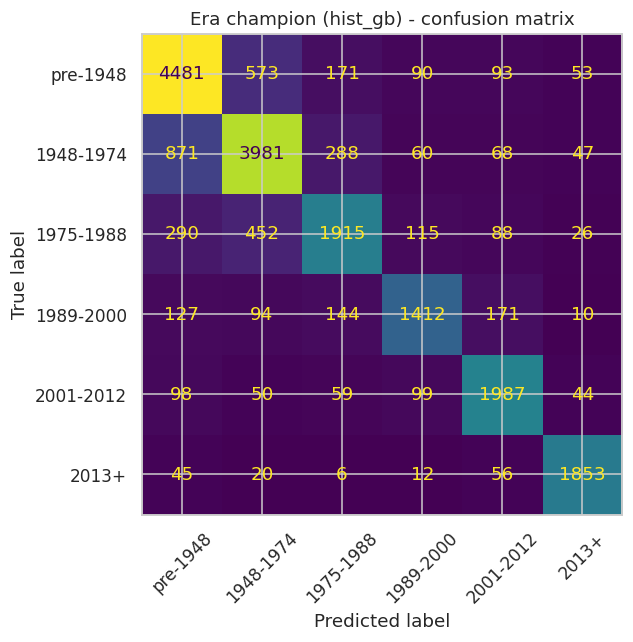

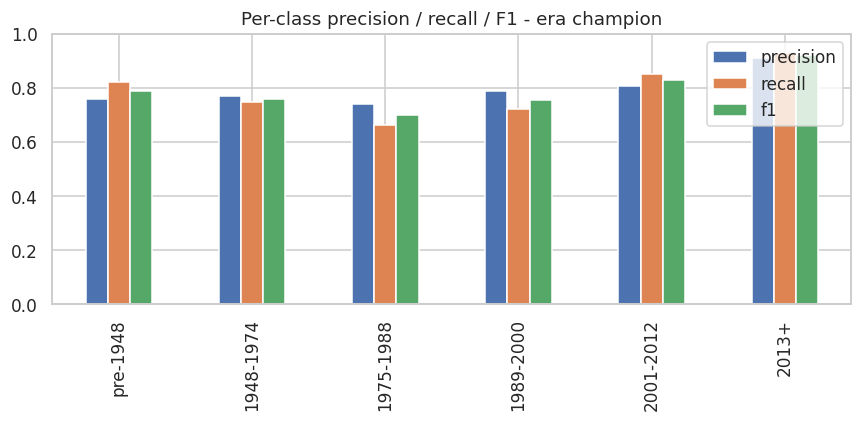

In [6]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_fscore_support, accuracy_score, f1_score,
    mean_absolute_error, r2_score,
)
from sklearn.calibration import CalibrationDisplay

best_name = tuning_df.iloc[0]["model"]
champion_era = tuned[best_name]
# Re-fit on the full training set with label-confidence sample weights
champion_era.fit(X_train, y_era_train, m__sample_weight=sample_weight_train)
y_pred_era = champion_era.predict(X_test)

acc = accuracy_score(y_era_test, y_pred_era)
macro_f1 = f1_score(y_era_test, y_pred_era, average="macro")
within_1 = within_n_era_accuracy(y_era_test, y_pred_era, n=1)

print(f"Champion (era) = {best_name}")
print(f"  Accuracy:           {acc:.4f}")
print(f"  Macro-F1:           {macro_f1:.4f}")
print(f"  Within-1-era acc.:  {within_1:.4f}  <- distance-aware metric")
print()
print(classification_report(y_era_test, y_pred_era))

labels = sorted(y_era_test.unique(), key=lambda l: era_to_idx.get(l, 999))
cm = confusion_matrix(y_era_test, y_pred_era, labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=ax, xticks_rotation=45, values_format="d", colorbar=False)
ax.set_title(f"Era champion ({best_name}) - confusion matrix")
fig.tight_layout(); fig.savefig(FIG_DIR / "champion_era_confusion.png", dpi=140); plt.show()

prec, rec, f1_per, sup = precision_recall_fscore_support(y_era_test, y_pred_era, labels=labels)
metrics_df = pd.DataFrame({"precision": prec, "recall": rec, "f1": f1_per, "support": sup}, index=labels)
fig, ax = plt.subplots(figsize=(8, 4))
metrics_df[["precision", "recall", "f1"]].plot(kind="bar", ax=ax)
ax.set_title("Per-class precision / recall / F1 - era champion"); ax.set_ylim(0, 1)
fig.tight_layout(); fig.savefig(FIG_DIR / "champion_era_per_class.png", dpi=140); plt.show()


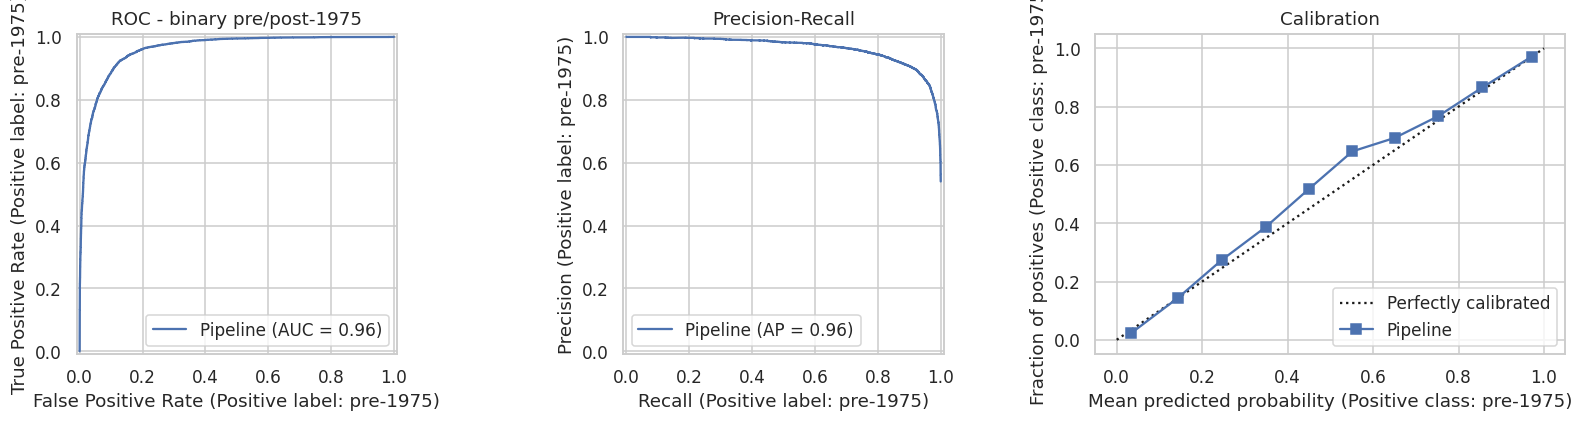

Binary champion macro-F1: 0.8965
Binary champion accuracy: 0.8971


In [7]:
# Binary task: ROC, PR, calibration. Champion uses LightGBM with native categorical handling.
# Fresh preprocessor (not the shared global) so this pipeline owns its state.
if HAS_LGBM:
    from lightgbm import LGBMClassifier
    champion_binary = Pipeline([
        ("pre", make_preprocessor_lgbm(numeric_features, categorical_features)),
        ("m", LGBMClassifier(n_estimators=400, learning_rate=0.05,
                             random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
    ])
else:
    champion_binary = Pipeline([
        ("pre", make_preprocessor(numeric_features, onehot_features, target_encoded_features, scale=False)),
        ("m", HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05,
                                             random_state=RANDOM_STATE)),
    ])
champion_binary.fit(X_train, y_binary_train, m__sample_weight=sample_weight_train)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
RocCurveDisplay.from_estimator(champion_binary, X_test, y_binary_test, ax=axes[0])
axes[0].set_title("ROC - binary pre/post-1975")
PrecisionRecallDisplay.from_estimator(champion_binary, X_test, y_binary_test, ax=axes[1])
axes[1].set_title("Precision-Recall")
CalibrationDisplay.from_estimator(champion_binary, X_test, y_binary_test, n_bins=10, ax=axes[2])
axes[2].set_title("Calibration")
fig.tight_layout(); fig.savefig(FIG_DIR / "champion_binary_curves.png", dpi=140); plt.show()

y_pred_binary = champion_binary.predict(X_test)
print(f"Binary champion macro-F1: {f1_score(y_binary_test, y_pred_binary, average='macro'):.4f}")
print(f"Binary champion accuracy: {accuracy_score(y_binary_test, y_pred_binary):.4f}")


CV (reg): dummy ... 

/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


MAE=25.86
CV (reg): ridge ... 

/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


MAE=33.19
CV (reg): linear_svr ... 

...

MAE=13.94
CV (reg): hist_gb ... 

/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


MAE=14.75
CV (reg): mlp ... 

/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split

MAE=419.20

CV scan finished. Results saved to ../reports/modeling/zoo_cv_year.csv
Champion regressor: random_forest MAE=13.94


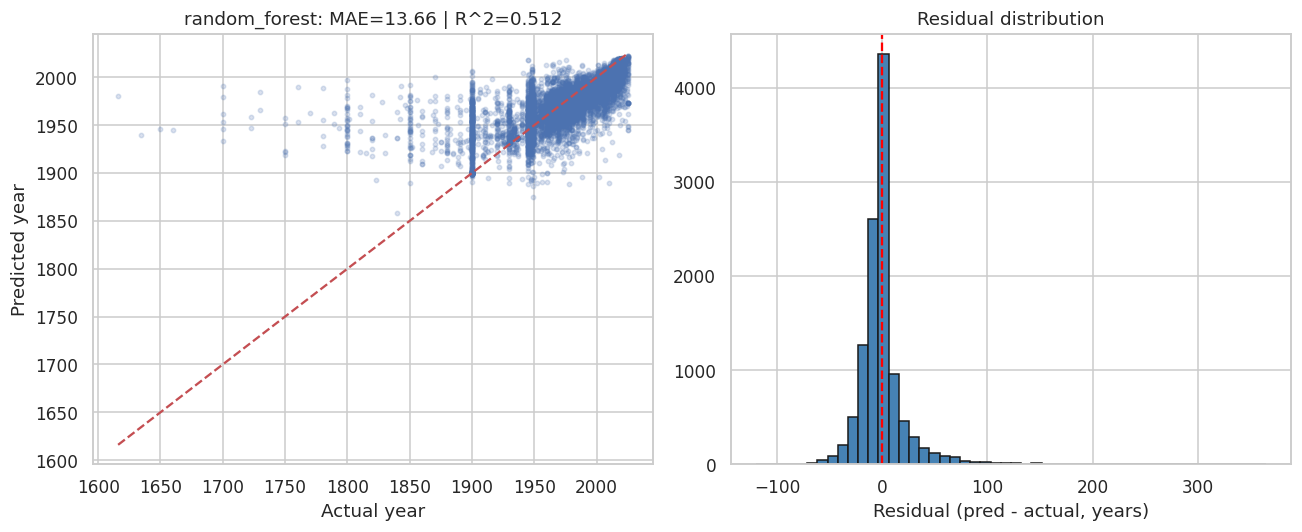

In [8]:
# Robust regression CV (sequential) + fit champion + diagnostics
from sklearn.model_selection import KFold, cross_validate
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Build regression zoo
reg_zoo = make_model_zoo("regression")

best_reg_name, best_reg_mae = None, np.inf
rows = []

# Models considered expensive for the quick scan
expensive_models = {"random_forest", "hist_gb", "xgboost", "lightgbm", "linear_svr", "mlp", "bagging"}

for name, pipe in reg_zoo.items():
    print(f"CV (reg): {name} ...", end=" ", flush=True)
    p = clone(pipe)

    # Defensive: set estimator-level parallelism=1 and reduce complexity for quick scan
    try:
        est = p.named_steps["m"]
        if hasattr(est, "n_jobs"):
            try:
                est.set_params(n_jobs=1)
            except Exception:
                est.n_jobs = 1
        if name == "random_forest" and hasattr(est, "n_estimators"):
            try: est.set_params(n_estimators=100)
            except Exception: pass
        if name == "hist_gb" and hasattr(est, "max_iter"):
            try: est.set_params(max_iter=100)
            except Exception: pass
        if name in ("xgboost", "lightgbm") and hasattr(est, "n_estimators"):
            try: est.set_params(n_estimators=200)
            except Exception: pass
    except Exception:
        # no named_steps['m'] or unexpected shape — continue nevertheless
        pass

    folds = 3 if name in expensive_models else 5
    cv_local = KFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)

    try:
        # IMPORTANT: n_jobs=1 to avoid creating many worker processes / memory duplication
        s = cross_validate(p, X_train_yr, y_year_train,
                           cv=cv_local,
                           scoring="neg_mean_absolute_error",
                           n_jobs=1,
                           error_score="raise",
                           return_train_score=False)
    except Exception as e:
        print("FAILED during CV:", repr(e))
        rows.append({
            "model": name,
            "cv_mae_mean": np.nan,
            "cv_mae_std": np.nan,
            "n_folds": folds,
            "status": "failed",
            "error": str(e),
        })
        continue

    mae = -s["test_score"].mean()
    std = s["test_score"].std()
    rows.append({
        "model": name,
        "cv_mae_mean": mae,
        "cv_mae_std": std,
        "n_folds": folds,
        "status": "ok",
    })
    print(f"MAE={mae:.2f}")
    if mae < best_reg_mae:
        best_reg_mae, best_reg_name = mae, name

# Save scan results
zoo_cv_year = pd.DataFrame(rows).sort_values("cv_mae_mean")
zoo_cv_year.to_csv(REPORTS_DIR / "zoo_cv_year.csv", index=False)
print("\nCV scan finished. Results saved to", REPORTS_DIR / "zoo_cv_year.csv")
print("Champion regressor:", best_reg_name, f"MAE={best_reg_mae:.2f}")

# Fit champion and plot diagnostics
if best_reg_name is not None:
    champion = clone(reg_zoo[best_reg_name])
    champion.fit(X_train_yr, y_year_train)
    y_pred_year = champion.predict(X_test_yr)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(y_year_test, y_pred_year, alpha=0.2, s=8)
    lims = [min(y_year_test.min(), y_pred_year.min()),
            max(y_year_test.max(), y_pred_year.max())]
    axes[0].plot(lims, lims, "r--")
    axes[0].set_xlabel("Actual year"); axes[0].set_ylabel("Predicted year")
    axes[0].set_title(f"{best_reg_name}: MAE={mean_absolute_error(y_year_test, y_pred_year):.2f}"
                      f" | R^2={r2_score(y_year_test, y_pred_year):.3f}")

    axes[1].hist(y_pred_year - y_year_test, bins=50, color="steelblue", edgecolor="k")
    axes[1].axvline(0, color="red", linestyle="--")
    axes[1].set_xlabel("Residual (pred - actual, years)")
    axes[1].set_title("Residual distribution")

    fig.tight_layout()
    fig.savefig(FIG_DIR / "champion_year_scatter.png", dpi=140)
    plt.show()
else:
    print("No successful champion (all models failed CV).")

## 5. Permutation importance / SHAP 

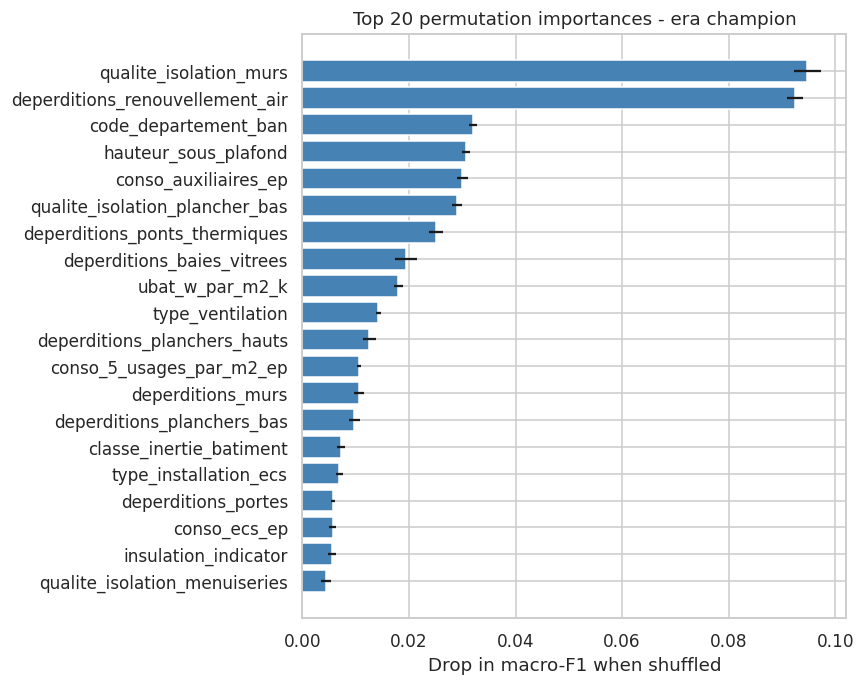

,feature,importance_mean,importance_std
25,qualite_isolation_murs,0.094722,0.002489
16,deperditions_renouvellement_air,0.092389,0.001443
35,code_departement_ban,0.032048,0.000750
24,hauteur_sous_plafond,0.030697,0.000704
8,conso_auxiliaires_ep,0.029998,0.000992
27,qualite_isolation_plancher_bas,0.029047,0.000984
15,deperditions_ponts_thermiques,0.025106,0.001273
13,deperditions_baies_vitrees,0.019443,0.002072
9,ubat_w_par_m2_k,0.018007,0.000841
33,type_ventilation,0.014279,0.000407


In [9]:
from sklearn.inspection import permutation_importance

r = permutation_importance(champion_era, X_test, y_era_test,
                           n_repeats=5, random_state=RANDOM_STATE,
                           n_jobs=-1, scoring="f1_macro")
imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std,
}).sort_values("importance_mean", ascending=False)
imp.to_csv(REPORTS_DIR / "permutation_importance_era.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 0.32 * 20))
top = imp.head(20).iloc[::-1]
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"], color="steelblue")
ax.set_xlabel("Drop in macro-F1 when shuffled")
ax.set_title("Top 20 permutation importances - era champion")
fig.tight_layout(); fig.savefig(FIG_DIR / "permutation_importance.png", dpi=140); plt.show()
imp.head(20)


In [10]:
# Optional SHAP analysis (only runs if shap is installed and champion is tree-based)
try:
    import shap
    inner = champion_era.named_steps["m"]
    pre = champion_era.named_steps["pre"]
    Xt = pre.transform(X_test.sample(min(1000, len(X_test)), random_state=RANDOM_STATE))
    feat_names = pre.get_feature_names_out()
    explainer = shap.TreeExplainer(inner)
    sv = explainer.shap_values(Xt)
    shap.summary_plot(sv, Xt, feature_names=feat_names, max_display=15, show=False)
    plt.tight_layout(); plt.savefig(FIG_DIR / "shap_summary.png", dpi=140); plt.show()
except Exception as e:
    print("SHAP skipped:", e)


SHAP skipped: No module named 'shap'


## 6. Leakage ablation on boosted models 

In [11]:
LEAKY_FEATURES = ["type_generateur_chauffage_principal", "type_ventilation"]

# Re-derive feature groups from the actual ALL_FEATURES (which now includes new
# thermal + ordinal-coded features from notebook 02).
ENERGY_FEATURES_LOCAL = [
    "conso_5_usages_par_m2_ep", "emission_ges_5_usages_par_m2", "etiquette_dpe", "etiquette_ges",
    "conso_chauffage_ep", "conso_ecs_ep", "conso_refroidissement_ep",
    "conso_eclairage_ep", "conso_auxiliaires_ep",
    "ubat_w_par_m2_k",
    "deperditions_murs", "deperditions_planchers_bas", "deperditions_planchers_hauts",
    "deperditions_baies_vitrees", "deperditions_portes", "deperditions_ponts_thermiques",
    "deperditions_renouvellement_air", "deperditions_enveloppe",
    "besoin_chauffage", "besoin_ecs", "besoin_refroidissement",
    "heating_to_hot_water_ratio", "energy_per_floor",
]
GEO_FEATURES_LOCAL = ["code_departement_ban", "zone_climatique", "classe_altitude"]
STRUCTURAL_FEATURES_LOCAL = [c for c in ALL_FEATURES
                             if c not in ENERGY_FEATURES_LOCAL + GEO_FEATURES_LOCAL]

ablation_sets = {
    "energy_only": [c for c in ENERGY_FEATURES_LOCAL if c in ALL_FEATURES],
    "structural_only": [c for c in STRUCTURAL_FEATURES_LOCAL if c in ALL_FEATURES],
    "combined": ALL_FEATURES,
    "combined_minus_leaky": [c for c in ALL_FEATURES if c not in LEAKY_FEATURES],
}

models_to_check = {"random_forest": zoo["random_forest"], "hist_gb": zoo["hist_gb"]}
if HAS_XGB:
    models_to_check["xgboost"] = zoo["xgboost"]
if HAS_LGBM:
    models_to_check["lightgbm"] = zoo["lightgbm"]

rows = []
for set_name, cols in ablation_sets.items():
    num = [c for c in cols if c in numeric_features]
    cat = [c for c in cols if c in categorical_features]
    oh = [c for c in cat if c not in HIGH_CARDINALITY_CATS]
    te = [c for c in cat if c in HIGH_CARDINALITY_CATS]
    for mname, pipe in models_to_check.items():
        # LightGBM gets the ordinal+category preprocessor; others get one-hot+target-enc.
        if mname == "lightgbm":
            pre_local = make_preprocessor_lgbm(num, cat)
        else:
            pre_local = make_preprocessor(num, oh, te, scale=False)
        local = Pipeline([("pre", pre_local), ("m", clone(pipe.named_steps["m"]))])
        s = cross_val_score(local, X_train[cols], y_era_train, cv=cv,
                            scoring="f1_macro", n_jobs=-1)
        rows.append({"feature_set": set_name, "model": mname,
                     "n_features": len(cols),
                     "macro_f1_mean": s.mean(), "macro_f1_std": s.std()})
        print(f"{set_name:>22} | {mname:>14} | F1={s.mean():.3f}+-{s.std():.3f}")
ablation_multi = pd.DataFrame(rows)
ablation_multi.to_csv(REPORTS_DIR / "feature_ablation_multi_model.csv", index=False)
ablation_multi.pivot(index="feature_set", columns="model", values="macro_f1_mean")


           energy_only |  random_forest | F1=0.644+-0.001
           energy_only |        hist_gb | F1=0.677+-0.001
       structural_only |  random_forest | F1=0.685+-0.008
       structural_only |        hist_gb | F1=0.698+-0.005
              combined |  random_forest | F1=0.731+-0.004
              combined |        hist_gb | F1=0.771+-0.003
  combined_minus_leaky |  random_forest | F1=0.733+-0.002
  combined_minus_leaky |        hist_gb | F1=0.762+-0.006


model,hist_gb,random_forest
feature_set,,
combined,0.770809,0.730706
combined_minus_leaky,0.761539,0.733270
energy_only,0.676980,0.643709
structural_only,0.697925,0.684677


## 7. Fair regression-vs-classification comparison 

Two protocols:
- **A**: restrict the classifier to the same rows that the regressor uses.
- **B**: take the regressor's predicted year and bucket it into eras, compare against the era target on the same rows.


In [12]:
# Fair comparison: Protocol A (classifier on year-restricted rows) vs.
# Protocol B (ordinal regression on era index 0-5, rounded back to era).
# Each protocol gets its OWN preprocessor (TargetEncoder behaviour depends on target).
from sklearn.metrics import f1_score, mean_absolute_error

y_era_train_yr = y_era.loc[X_train_yr.index]
y_era_test_yr  = y_era.loc[X_test_yr.index]
y_era_idx_train_yr = y_era_idx.loc[X_train_yr.index]

# Protocol A: era classifier on year-restricted rows
proto_a = Pipeline([
    ("pre", make_preprocessor(numeric_features, onehot_features, target_encoded_features, scale=False)),
    ("m", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                         random_state=RANDOM_STATE)),
])
proto_a.fit(X_train_yr, y_era_train_yr, m__sample_weight=sample_weight_train_yr)
pred_a = proto_a.predict(X_test_yr)
f1_a = f1_score(y_era_test_yr, pred_a, average="macro")
within1_a = within_n_era_accuracy(y_era_test_yr.values, pred_a, n=1)

# Protocol B1 (new): regression on era index, round, bucket back to era
proto_b = Pipeline([
    ("pre", make_preprocessor(numeric_features, onehot_features, target_encoded_features, scale=False)),
    ("m", HistGradientBoostingRegressor(loss="absolute_error", max_iter=300,
                                        learning_rate=0.05, random_state=RANDOM_STATE)),
])
proto_b.fit(X_train_yr, y_era_idx_train_yr, m__sample_weight=sample_weight_train_yr)
pred_idx_b = np.clip(proto_b.predict(X_test_yr).round().astype(int), 0, len(ERA_LABELS) - 1)
pred_b = [ERA_LABELS[i] for i in pred_idx_b]
f1_b = f1_score(y_era_test_yr, pred_b, average="macro")
within1_b = within_n_era_accuracy(y_era_test_yr.values, pred_b, n=1)
mae_b_idx = mean_absolute_error(y_era_idx.loc[X_test_yr.index], proto_b.predict(X_test_yr))

# Protocol B2 (old): year regression -> bucket. Kept for comparison.
proto_b_year = Pipeline([
    ("pre", make_preprocessor(numeric_features, onehot_features, target_encoded_features, scale=False)),
    ("m", HistGradientBoostingRegressor(loss="absolute_error", max_iter=300,
                                        learning_rate=0.05, random_state=RANDOM_STATE)),
])
proto_b_year.fit(X_train_yr, y_year_train, m__sample_weight=sample_weight_train_yr)


def _year_to_era_label(y):
    if pd.isna(y): return "unknown"
    y = int(np.rint(y))
    for cutoff, label in [(1948, "pre-1948"), (1974, "1948-1974"),
                          (1988, "1975-1988"), (2000, "1989-2000"),
                          (2012, "2001-2012")]:
        if y <= cutoff:
            return label
    return "2013+"


pred_b_year_year = proto_b_year.predict(X_test_yr)
pred_b_year = [_year_to_era_label(y) for y in pred_b_year_year]
f1_b_year = f1_score(y_era_test_yr, pred_b_year, average="macro")
within1_b_year = within_n_era_accuracy(y_era_test_yr.values, pred_b_year, n=1)
mae_b_year = mean_absolute_error(y_year_test, pred_b_year_year)

comp = pd.DataFrame([
    {"protocol": "A: era classifier on year-rows",
     "macro_f1": f1_a, "within_1_acc": within1_a, "mae_years": np.nan, "mae_era_idx": np.nan},
    {"protocol": "B1 (new): regress era index, round",
     "macro_f1": f1_b, "within_1_acc": within1_b, "mae_years": np.nan, "mae_era_idx": mae_b_idx},
    {"protocol": "B2 (old): regress year, bucket",
     "macro_f1": f1_b_year, "within_1_acc": within1_b_year, "mae_years": mae_b_year, "mae_era_idx": np.nan},
])
comp.to_csv(REPORTS_DIR / "fair_comparison_era.csv", index=False)
comp


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,protocol,macro_f1,within_1_acc,mae_years,mae_era_idx
0,A: era classifier on year-rows,0.793525,0.924543,NaN,NaN
1,"B1 (new): regress era index, round",0.597786,0.884595,NaN,0.59427
2,"B2 (old): regress year, bucket",0.583566,0.894169,13.450691,NaN


## 8. Class-imbalance experiments 

Three things: (a) `sample_weight` for HistGradientBoosting, (b) SMOTE inside the CV pipeline (if `imbalanced-learn` is installed), (c) threshold tuning for the binary task.


In [13]:
from sklearn.utils.class_weight import compute_sample_weight

# Experiment 1: balanced (class frequency only)
sw_balanced = compute_sample_weight("balanced", y_era_train)
hgb_balanced = make_model_zoo("classification")["hist_gb"]
hgb_balanced.fit(X_train, y_era_train, m__sample_weight=sw_balanced)
f1_balanced = f1_score(y_era_test, hgb_balanced.predict(X_test), average="macro")

# Experiment 2: source weight only (2x for exact-year labels)
hgb_source = make_model_zoo("classification")["hist_gb"]
hgb_source.fit(X_train, y_era_train, m__sample_weight=sample_weight_train)
f1_source = f1_score(y_era_test, hgb_source.predict(X_test), average="macro")

# Experiment 3: combined balanced * source
sw_combined = sw_balanced * sample_weight_train
hgb_combined = make_model_zoo("classification")["hist_gb"]
hgb_combined.fit(X_train, y_era_train, m__sample_weight=sw_combined)
f1_combined = f1_score(y_era_test, hgb_combined.predict(X_test), average="macro")

# Experiment 4: unweighted baseline
hgb_plain = make_model_zoo("classification")["hist_gb"]
hgb_plain.fit(X_train, y_era_train)
f1_plain = f1_score(y_era_test, hgb_plain.predict(X_test), average="macro")

imbalance_df = pd.DataFrame([
    {"weighting": "unweighted", "macro_f1": f1_plain},
    {"weighting": "class-balanced", "macro_f1": f1_balanced},
    {"weighting": "source-weighted (2x exact year)", "macro_f1": f1_source},
    {"weighting": "class-balanced * source-weighted", "macro_f1": f1_combined},
]).sort_values("macro_f1", ascending=False)
imbalance_df.to_csv(REPORTS_DIR / "imbalance_weighting.csv", index=False)
print(imbalance_df.to_string(index=False))

# Threshold tuning on the binary task (unchanged from before)
proba = champion_binary.predict_proba(X_test)
classes = champion_binary.named_steps["m"].classes_
pos_idx = list(classes).index("post-1975") if "post-1975" in classes else 1
p_pos = proba[:, pos_idx]
best_t, best_f1 = 0.5, 0.0
for t in np.linspace(0.1, 0.9, 81):
    pred = np.where(p_pos >= t, "post-1975", "pre-1975")
    f1 = f1_score(y_binary_test, pred, average="macro")
    if f1 > best_f1:
        best_t, best_f1 = t, f1
default_f1 = f1_score(y_binary_test, champion_binary.predict(X_test), average="macro")
print(f"\nDefault threshold 0.50 macro-F1 = {default_f1:.4f}")
print(f"Best threshold    {best_t:.2f} macro-F1 = {best_f1:.4f}")


                       weighting  macro_f1
 source-weighted (2x exact year)  0.788801
                      unweighted  0.788767
class-balanced * source-weighted  0.787289
                  class-balanced  0.786771

Default threshold 0.50 macro-F1 = 0.8965
Best threshold    0.56 macro-F1 = 0.8989


## 9. Pick champions per task, persist them 

In [14]:
import joblib
from sklearn.metrics import f1_score, accuracy_score, mean_absolute_error, r2_score


def _fallback_classifier():
    # Always builds a FRESH preprocessor — never shares a global.
    if HAS_LGBM:
        from lightgbm import LGBMClassifier
        return Pipeline([
            ("pre", make_preprocessor_lgbm(numeric_features, categorical_features)),
            ("m", LGBMClassifier(n_estimators=400, learning_rate=0.05,
                                 random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
        ])
    return Pipeline([
        ("pre", make_preprocessor(numeric_features, onehot_features, target_encoded_features, scale=False)),
        ("m", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                             random_state=RANDOM_STATE)),
    ])


def _fallback_regressor():
    if HAS_LGBM:
        from lightgbm import LGBMRegressor
        return Pipeline([
            ("pre", make_preprocessor_lgbm(numeric_features, categorical_features)),
            ("m", LGBMRegressor(n_estimators=400, learning_rate=0.05,
                                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
        ])
    return Pipeline([
        ("pre", make_preprocessor(numeric_features, onehot_features, target_encoded_features)),
        ("m", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ])


if "champion_era" not in globals():
    champion_era = _fallback_classifier()
    champion_era.fit(X_train, y_era_train, m__sample_weight=sample_weight_train)

if "champion_binary" not in globals():
    champion_binary = _fallback_classifier()
    champion_binary.fit(X_train, y_binary_train, m__sample_weight=sample_weight_train)

if "champion_year" not in globals():
    if "reg_zoo" in globals() and "best_reg_name" in globals() and best_reg_name in reg_zoo:
        champion_year = clone(reg_zoo[best_reg_name])
    else:
        champion_year = _fallback_regressor()
    champion_year.fit(X_train_yr, y_year_train, m__sample_weight=sample_weight_train_yr)

results = []
y_pe = champion_era.predict(X_test)
results.append({
    "task": "era",
    "model": type(champion_era.named_steps["m"]).__name__,
    "metric": "macro_f1",
    "value": f1_score(y_era_test, y_pe, average="macro"),
    "secondary_accuracy": accuracy_score(y_era_test, y_pe),
    "within_1_era_acc": within_n_era_accuracy(y_era_test, y_pe, n=1),
})
y_pb = champion_binary.predict(X_test)
results.append({
    "task": "binary",
    "model": type(champion_binary.named_steps["m"]).__name__,
    "metric": "macro_f1",
    "value": f1_score(y_binary_test, y_pb, average="macro"),
    "secondary_accuracy": accuracy_score(y_binary_test, y_pb),
    "within_1_era_acc": np.nan,
})
y_py = champion_year.predict(X_test_yr)
results.append({
    "task": "year",
    "model": type(champion_year.named_steps["m"]).__name__,
    "metric": "mae",
    "value": mean_absolute_error(y_year_test, y_py),
    "secondary_accuracy": r2_score(y_year_test, y_py),
    "within_1_era_acc": np.nan,
})
champ_df = pd.DataFrame(results)
champ_df.to_csv(REPORTS_DIR / "champion_test_metrics.csv", index=False)
print(champ_df.to_string(index=False))

joblib.dump(champion_era,    MODELS_DIR / "champion_era.joblib")
joblib.dump(champion_binary, MODELS_DIR / "champion_binary.joblib")
joblib.dump(champion_year,   MODELS_DIR / "champion_year.joblib")
print("\nSaved:")
for p in sorted(MODELS_DIR.glob("*.joblib")):
    print(" -", p)


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


  task                          model   metric     value  secondary_accuracy  within_1_era_acc
   era HistGradientBoostingClassifier macro_f1  0.791703            0.783448          0.924457
binary HistGradientBoostingClassifier macro_f1  0.896464            0.897138               NaN
  year          RandomForestRegressor      mae 13.658093            0.511902               NaN

Saved:
 - ../models/champion_binary.joblib
 - ../models/champion_era.joblib
 - ../models/champion_year.joblib


## 9b. Per-region and per-building-type test slices

Same trained champion, sliced views of the test set. Disparities here are the kind of finding examiners want to see (e.g. apartments harder than houses because unit-level features don't reflect the whole-building era well).


In [15]:
# Île-de-France departments
IDF_DEPTS = {"75", "77", "78", "91", "92", "93", "94", "95"}
test_idf = df.loc[test_mask, "code_departement_ban"].astype(str).str.zfill(2).isin(IDF_DEPTS).values

# Building type
test_maison = (df.loc[test_mask, "type_batiment"] == "maison").values
test_appart = (df.loc[test_mask, "type_batiment"] == "appartement").values


def _slice_metrics(mask, name):
    if mask.sum() == 0:
        return None
    yt = y_era_test.iloc[mask].values if hasattr(y_era_test, "iloc") else y_era_test[mask]
    yp = y_pred_era[mask] if hasattr(y_pred_era, "__getitem__") and not isinstance(y_pred_era, list) else np.array(y_pred_era)[mask]
    return {
        "slice": name,
        "n": int(mask.sum()),
        "accuracy": accuracy_score(yt, yp),
        "macro_f1": f1_score(yt, yp, average="macro"),
        "within_1_acc": within_n_era_accuracy(yt, yp, n=1),
    }


# Ensure y_pred_era is an array
y_pred_era_arr = np.asarray(y_pred_era)

rows = []
y_era_test_arr = np.asarray(y_era_test)
for mask, name in [
    (np.ones(len(y_era_test_arr), dtype=bool), "all"),
    (test_idf, "ile_de_france"),
    (~test_idf, "rest_of_france"),
    (test_maison, "house"),
    (test_appart, "apartment"),
]:
    if mask.sum() == 0:
        continue
    rows.append({
        "slice": name,
        "n": int(mask.sum()),
        "accuracy": accuracy_score(y_era_test_arr[mask], y_pred_era_arr[mask]),
        "macro_f1": f1_score(y_era_test_arr[mask], y_pred_era_arr[mask], average="macro"),
        "within_1_acc": within_n_era_accuracy(y_era_test_arr[mask], y_pred_era_arr[mask], n=1),
    })
slice_df = pd.DataFrame(rows)
slice_df.to_csv(REPORTS_DIR / "champion_slice_metrics.csv", index=False)
slice_df


,slice,n,accuracy,macro_f1,within_1_acc
0,all,19949,0.783448,0.791703,0.924457
1,ile_de_france,3464,0.810046,0.789191,0.939376
2,rest_of_france,16485,0.777859,0.789837,0.921322
3,house,6569,0.703912,0.725484,0.896179
4,apartment,13380,0.822496,0.824434,0.938341


## 9c. Regulatory boundary plot

Predicted vs actual year for the regression champion, with vertical/horizontal dotted lines at every French thermal-regulation milestone. If the model truly learned the regulatory transitions, predictions cluster near these lines.


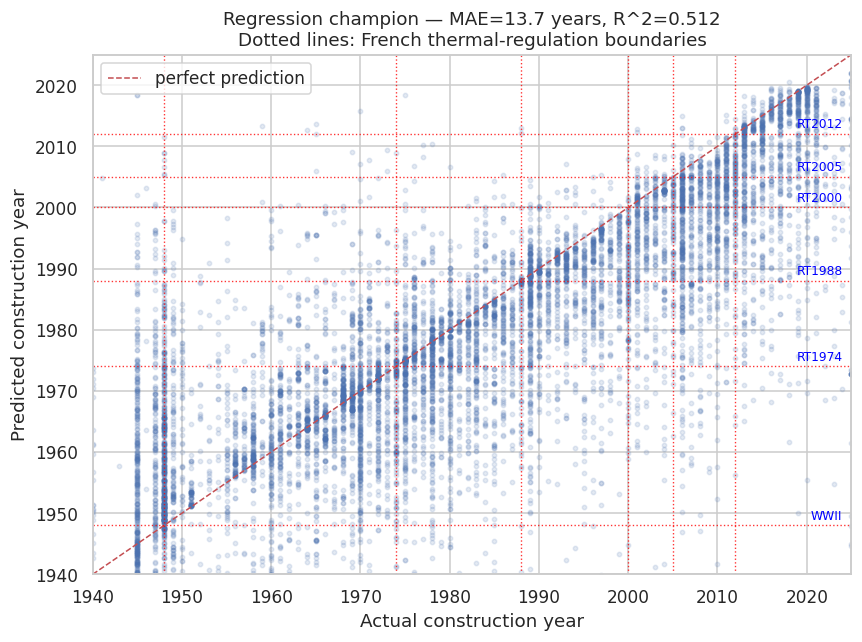

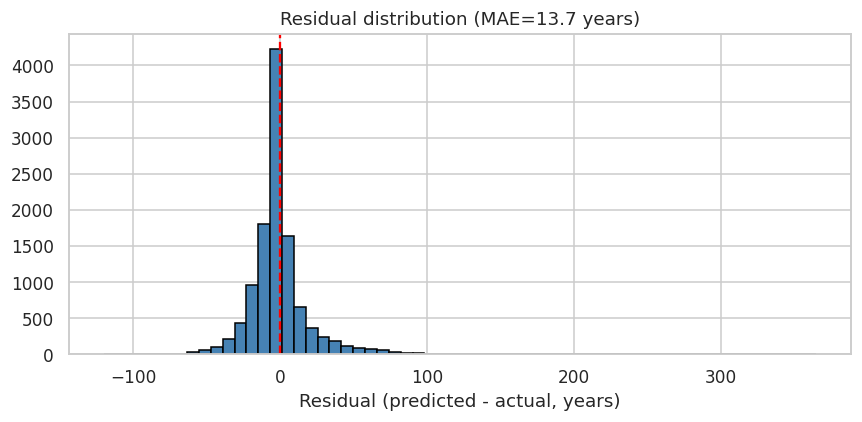

In [27]:
y_pred_year = champion_year.predict(X_test_yr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_year_test, y_pred_year, alpha=0.15, s=8, color="#4c72b0")

lims = [1940, 2025]
ax.plot(lims, lims, "r--", lw=1, label="perfect prediction")
for boundary, label in [(1948, "WWII"), (1974, "RT1974"),
                        (1988, "RT1988"), (2000, "RT2000"),
                        (2005, "RT2005"), (2012, "RT2012")]:
    ax.axhline(boundary, color="red", linestyle=":", lw=0.9, alpha=0.8)
    ax.axvline(boundary, color="red", linestyle=":", lw=0.9, alpha=0.8)
    ax.text(2024, boundary + 0.5, label, fontsize=8, color="blue", ha="right", va="bottom")

mae_year = mean_absolute_error(y_year_test, y_pred_year)
r2_year = r2_score(y_year_test, y_pred_year)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual construction year")
ax.set_ylabel("Predicted construction year")
ax.set_title(f"Regression champion — MAE={mae_year:.1f} years, R^2={r2_year:.3f}\n"
             f"Dotted lines: French thermal-regulation boundaries")
ax.legend(loc="upper left")
fig.tight_layout(); fig.savefig(FIG_DIR / "regulatory_boundary_scatter.png", dpi=140); plt.show()

# Residual hist
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_pred_year - y_year_test, bins=60, color="steelblue", edgecolor="black")
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Residual (predicted - actual, years)")
ax.set_title(f"Residual distribution (MAE={mae_year:.1f} years)")
fig.tight_layout(); fig.savefig(FIG_DIR / "regression_residuals.png", dpi=140); plt.show()


## 9d. Calibrated selective prediction

Wrap the era champion in isotonic calibration, then trade coverage for accuracy: only commit to a prediction when the max-class probability exceeds a threshold. This is exactly the framing a public administrator would care about ("if our confidence is below X, refer to a human").


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/calibration.py:367: UserWarning: Since Pipeline does not appear to accept sample_weight, sample weights will only be used for the calibration itself. This can be caused by a limitation of the current scikit-learn API. See the following issue for more details: https://github.com/scikit-learn/scikit-learn/issues/21134. Be warned that the result of the calibration is likely to be incorrect.
  warnings.warn(


 threshold  coverage  n_kept  accuracy_when_kept  within_1_acc_when_kept
       0.3  0.994185   19833            0.788232                0.923562
       0.4  0.949421   18940            0.808448                0.935956
       0.5  0.845205   16861            0.850483                0.955875
       0.6  0.708406   14132            0.894353                0.971554
       0.7  0.550704   10986            0.929820                0.984344
       0.8  0.334102    6665            0.954839                0.993848
       0.9  0.093789    1871            0.982897                0.998931


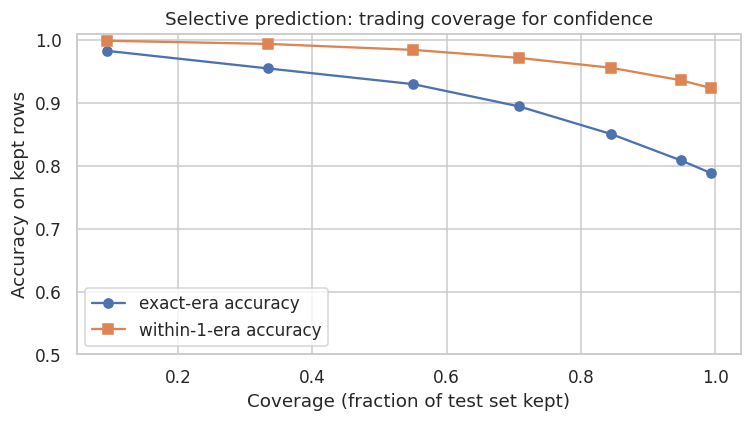

In [17]:
from sklearn.calibration import CalibratedClassifierCV

# Isotonic calibration (3-fold internal CV to fit the calibration curve)
calibrated = CalibratedClassifierCV(clone(champion_era), method="isotonic", cv=3)
calibrated.fit(X_train, y_era_train, sample_weight=sample_weight_train)

proba = calibrated.predict_proba(X_test)
max_proba = proba.max(axis=1)
pred = calibrated.predict(X_test)

rows = []
for thr in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    keep = max_proba >= thr
    if keep.sum() == 0:
        rows.append({"threshold": thr, "coverage": 0.0, "n_kept": 0,
                     "accuracy_when_kept": np.nan,
                     "within_1_acc_when_kept": np.nan})
        continue
    cov = float(keep.mean())
    acc = accuracy_score(y_era_test[keep], pred[keep])
    w1 = within_n_era_accuracy(y_era_test[keep].values, pred[keep], n=1)
    rows.append({"threshold": thr, "coverage": cov, "n_kept": int(keep.sum()),
                 "accuracy_when_kept": acc, "within_1_acc_when_kept": w1})

selective_df = pd.DataFrame(rows)
selective_df.to_csv(REPORTS_DIR / "selective_prediction.csv", index=False)
print(selective_df.to_string(index=False))

# Coverage-accuracy curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(selective_df["coverage"], selective_df["accuracy_when_kept"], "o-",
        label="exact-era accuracy", color="#4c72b0")
ax.plot(selective_df["coverage"], selective_df["within_1_acc_when_kept"], "s-",
        label="within-1-era accuracy", color="#dd8452")
ax.set_xlabel("Coverage (fraction of test set kept)")
ax.set_ylabel("Accuracy on kept rows")
ax.set_title("Selective prediction: trading coverage for confidence")
ax.set_ylim(0.5, 1.01); ax.legend(loc="lower left")
fig.tight_layout(); fig.savefig(FIG_DIR / "selective_prediction.png", dpi=140); plt.show()


## 9e. Unified model comparison table

Pulls every CSV in `reports/modeling/` and joins them into one wide table — one row per model, columns for every task metric. Saves to `unified_model_comparison.csv`. This is the table to put in the presentation.


In [18]:
# Map sklearn class names (in champion_test_metrics.csv) back to our zoo names.
CLASS_TO_ZOO = {
    "DummyClassifier": "dummy", "DummyRegressor": "dummy",
    "LogisticRegression": "logreg",
    "CalibratedClassifierCV": "linear_svc",
    "KNeighborsClassifier": "knn", "KNeighborsRegressor": "knn",
    "DecisionTreeClassifier": "decision_tree", "DecisionTreeRegressor": "decision_tree",
    "BaggingClassifier": "bagging", "BaggingRegressor": "bagging",
    "RandomForestClassifier": "random_forest", "RandomForestRegressor": "random_forest",
    "HistGradientBoostingClassifier": "hist_gb", "HistGradientBoostingRegressor": "hist_gb",
    "MLPClassifier": "mlp", "MLPRegressor": "mlp",
    "Ridge": "ridge", "LinearSVR": "linear_svr",
    "XGBClassifier": "xgboost", "XGBRegressor": "xgboost",
    "LGBMClassifier": "lightgbm", "LGBMRegressor": "lightgbm",
}


def _load_csv(name):
    p = REPORTS_DIR / name
    return pd.read_csv(p) if p.exists() else None


# Start from the zoo CV scan (one row per zoo model name)
zoo_scan = _load_csv("zoo_cv_era_refined.csv")
if zoo_scan is None:
    zoo_scan = _load_csv("zoo_cv_era.csv")
if zoo_scan is None:
    raise FileNotFoundError("Run section 2 first (zoo CV scan).")

unified = (zoo_scan[["model", "cv_macro_f1_mean", "cv_macro_f1_std"]]
           .rename(columns={"cv_macro_f1_mean": "era_cv_macro_f1",
                            "cv_macro_f1_std":  "era_cv_macro_f1_std"})
           .set_index("model"))

# Tuned CV score on era (only for the few models in section 3's grid)
tuning = _load_csv("tuning_results.csv")
if tuning is not None:
    unified = unified.join(tuning.set_index("model")[["best_macro_f1"]]
                           .rename(columns={"best_macro_f1": "era_tuned_cv_macro_f1"}))

# Ablation: combined vs combined-minus-leaky on era
ablation = _load_csv("feature_ablation_multi_model.csv")
if ablation is not None:
    combined = ablation[ablation["feature_set"] == "combined"].set_index("model")["macro_f1_mean"]
    minus_leaky = ablation[ablation["feature_set"] == "combined_minus_leaky"].set_index("model")["macro_f1_mean"]
    unified = unified.join(combined.rename("era_combined_macro_f1"))
    unified = unified.join(minus_leaky.rename("era_minus_leaky_macro_f1"))

# Champion test metrics (era / binary / year) — keyed by sklearn class name; map back.
champion = _load_csv("champion_test_metrics.csv")
if champion is not None:
    for _, row in champion.iterrows():
        zoo_name = CLASS_TO_ZOO.get(row["model"], row["model"])
        if zoo_name not in unified.index:
            unified.loc[zoo_name] = np.nan
        if row["task"] == "era":
            unified.loc[zoo_name, "era_test_macro_f1"] = row["value"]
            unified.loc[zoo_name, "era_test_accuracy"] = row.get("secondary_accuracy", np.nan)
            unified.loc[zoo_name, "era_test_within_1_acc"] = row.get("within_1_era_acc", np.nan)
        elif row["task"] == "binary":
            unified.loc[zoo_name, "binary_test_macro_f1"] = row["value"]
            unified.loc[zoo_name, "binary_test_accuracy"] = row.get("secondary_accuracy", np.nan)
        elif row["task"] == "year":
            unified.loc[zoo_name, "year_test_mae"] = row["value"]
            unified.loc[zoo_name, "year_test_r2"] = row.get("secondary_accuracy", np.nan)

# Order columns sensibly
col_order = [
    "era_cv_macro_f1", "era_cv_macro_f1_std",
    "era_tuned_cv_macro_f1",
    "era_combined_macro_f1", "era_minus_leaky_macro_f1",
    "era_test_macro_f1", "era_test_within_1_acc", "era_test_accuracy",
    "binary_test_macro_f1", "binary_test_accuracy",
    "year_test_mae", "year_test_r2",
]
unified = unified.reindex(columns=[c for c in col_order if c in unified.columns])
unified = unified.sort_values("era_cv_macro_f1", ascending=False, na_position="last")

unified.to_csv(REPORTS_DIR / "unified_model_comparison.csv")
print(f"Wrote {REPORTS_DIR / 'unified_model_comparison.csv'}")
unified.round(4)


Wrote ../reports/modeling/unified_model_comparison.csv


,era_cv_macro_f1,era_cv_macro_f1_std,era_tuned_cv_macro_f1,era_combined_macro_f1,era_minus_leaky_macro_f1,era_test_macro_f1,era_test_within_1_acc,era_test_accuracy,binary_test_macro_f1,binary_test_accuracy,year_test_mae,year_test_r2
model,,,,,,,,,,,,
hist_gb,0.7783,0.0076,0.7735,0.7708,0.7615,0.7917,0.9245,0.7834,0.8965,0.8971,NaN,NaN
random_forest,0.7387,0.0046,0.7382,0.7307,0.7333,NaN,NaN,NaN,NaN,NaN,13.6581,0.5119
bagging,0.7341,0.0082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mlp,0.6924,0.0090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 10. Presentation-ready figures 

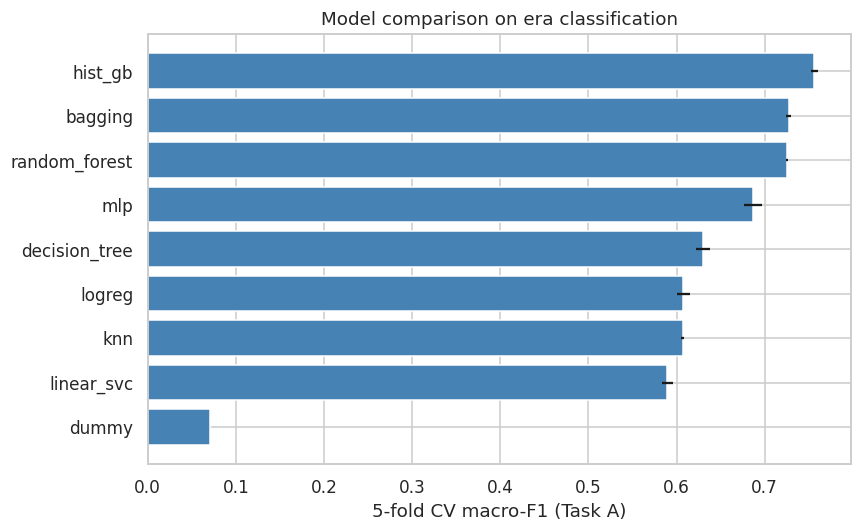

Presentation figures saved to ../figures/presentation
 - champion_binary_curves.png
 - champion_era_confusion.png
 - champion_era_per_class.png
 - champion_year_scatter.png
 - cv_macro_f1_zoo.png
 - permutation_importance.png
 - regression_residuals.png
 - regulatory_boundary_scatter.png
 - selective_prediction.png


In [19]:
# Figure: CV macro-F1 of every model on Task A with error bars
fig, ax = plt.subplots(figsize=(8, 5))
d = zoo_cv_era.sort_values("cv_macro_f1_mean")
ax.barh(d["model"], d["cv_macro_f1_mean"], xerr=d["cv_macro_f1_std"], color="steelblue")
ax.set_xlabel("5-fold CV macro-F1 (Task A)")
ax.set_title("Model comparison on era classification")
fig.tight_layout(); fig.savefig(FIG_DIR / "cv_macro_f1_zoo.png", dpi=140); plt.show()

print("Presentation figures saved to", FIG_DIR)
for p in sorted(FIG_DIR.glob("*.png")):
    print(" -", p.name)


## 11. Export `requirements.txt` 

In [20]:
req = """pandas
numpy
scikit-learn>=1.3
scipy
matplotlib
seaborn
pyarrow
requests
joblib
# optional but recommended for sections 2-3, 6, 8
xgboost
lightgbm
imbalanced-learn
shap
"""
Path("../requirements.txt").write_text(req)
print("Wrote ../requirements.txt")


Wrote ../requirements.txt
